# MLMarker Tissue Similarity — Cell line HepG2


In [1]:
%pip install mlmarker
%pip install --upgrade openpyxl --force-reinstall

Note: you may need to restart the kernel to use updated packages.
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

  Attempting uninstall: et-xmlfile

    Found existing installation: et_xmlfile 2.0.0

    Uninstalling et_xmlfile-2.0.0:

      Successfully uninstalled et_xmlfile-2.0.0

  Attempting uninstall: openpyxl

    Found existing installation: openpyxl 3.1.5

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
    Uninstalling openpyxl-3.1.5:
   -------------------- ------------------- 1/2 [openpyxl]
      Successfully uninstalled openpyxl-3.1.5
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from mlmarker import MLMarker

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


## 1. Configuration

In [16]:
# --- Sample / experiment identifiers -----------------------------------------
cmb = "CMB-2219_1_20"
baseline = "P0"
passage = "P19"

# --- Model output size ---------------------------------------------------------

N_TISSUES = 34

# --- SHAP driver settings -------------------------------------------------------

N_SHAP_DRIVERS_EACH = 20

# Data paths 
PROTEIN_INTENSITY_PATH = (
    "C:/Users/kator/DATA/Ugent2025-2026/Master Dissertation/"
    "Scripts data analyse/Datasets/results/CMB-2219_1_20/Protein_Intensities_Wide.csv"
)
DEA_DIR = (
    f"C:/Users/kator/DATA/Ugent2025-2026/Master Dissertation/Scripts data analyse/"
    f"Datasets/results/{cmb}/{passage}_vs_{baseline}/dea_lists"
)

## 2. Load & scale protein data

In [17]:
df = pd.read_csv(PROTEIN_INTENSITY_PATH, index_col=0)

print(df.index[:5])
print(df.shape)

Index(['1_1', '1_2', '1_3', '2_1', '2_2'], dtype='object')
(57, 4537)


In [18]:
scaler = MinMaxScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df.T).T,
    columns=df.columns,
    index=df.index,
)

## 3. Run MLMarker per sample

For every sample this now stores:
- **every** tissue prediction (up to `N_TISSUES`), so we can build the full
  ranked table
- the SHAP dataframe (`shap_results`), pulled with the same `N_TISSUES` so that whichever
  tissue ends up on top (e.g. B-cell) is guaranteed to be explainable

In [19]:
model = MLMarker(binary=False, penalty_factor=1)

prediction_records = []   # long-format: one row per (sample, rank/tissue)
shap_results = {}         # sample_id -> full SHAP dataframe (tissues x proteins)

for sample_name, protein_data in df_scaled.iterrows():
    sample_df = pd.DataFrame(protein_data).T

    try:
        # Parse passage number and replicate ID (assumes naming like '1_1')
        sample_parts = str(sample_name).split("_")
        raw_passage = int(sample_parts[0])
        passage_num = raw_passage - 1
        replicate_id = sample_parts[1] if len(sample_parts) > 1 else "1"

        model.load_sample(sample_df)
        predictions = model.predict_top_tissues_shap(n_preds=N_TISSUES)

        # Store every tissue prediction with its rank
        for rank, (tissue, prob) in enumerate(predictions, start=1):
            prediction_records.append(
                {
                    "Sample": sample_name,
                    "Passage": passage_num,
                    "Replicate": f"Rep {replicate_id}",
                    "Rank": rank,
                    "Tissue": tissue.strip(),
                    "Probability": prob,
                }
            )

        print(f"Processing: {sample_name} (Passage {passage_num}, Rep {replicate_id})")

        # Pull SHAP values across the same number of tissues so the top-predicted
        # tissue (e.g. B-cell) is always included, not just Lung
        shap_df = model.explainability.get_shap_values(n_preds=N_TISSUES)
        shap_results[sample_name] = shap_df

    except Exception as e:
        print(f"Error processing sample {sample_name}: {e}")

df_predictions_long = pd.DataFrame(prediction_records).sort_values(
    ["Passage", "Replicate", "Rank"]
).reset_index(drop=True)

df_predictions_long.head(N_TISSUES)

Trying to unpickle estimator DecisionTreeClassifier from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
Trying to unpickle estimator RandomForestClassifier from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


Processing: 1_1 (Passage 0, Rep 1)


The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


Processing: 1_2 (Passage 0, Rep 2)


The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


...

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


Processing: 20_2 (Passage 19, Rep 2)


The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


Processing: 20_3 (Passage 19, Rep 3)


,Sample,Passage,Replicate,Rank,Tissue,Probability
0,1_1,0,Rep 1,1,B-cells,0.1782
1,1_1,0,Rep 1,2,Parotid gland,0.0943
2,1_1,0,Rep 1,3,Tonsil,0.0869
3,1_1,0,Rep 1,4,Testis,0.0861
4,1_1,0,Rep 1,5,Pituitary gland,0.0562
5,1_1,0,Rep 1,6,Skeletal muscle,0.0511
6,1_1,0,Rep 1,7,Ovary,0.0466
7,1_1,0,Rep 1,8,Salivary gland,0.0417
8,1_1,0,Rep 1,9,Kidney,0.0409
9,1_1,0,Rep 1,10,Adrenal gland,0.0403


## 4. Clear top-34 prediction table

Two views:
- **Wide table**: one row per sample, one column per tissue, values = predicted probability
  (rank order preserved by mean probability across samples).
- **Rank summary**: for each sample, the #1 predicted tissue and where Lung specifically
  ranks 


In [20]:
# Wide table: Sample x Tissue probability matrix, ordered by average probability
df_predictions_wide = df_predictions_long.pivot_table(
    index="Sample", columns="Tissue", values="Probability"
)
tissue_order = df_predictions_wide.mean(axis=0).sort_values(ascending=False).index
df_predictions_wide = df_predictions_wide[tissue_order]

df_predictions_wide

Tissue,B-cells,Parotid gland,Testis,Tonsil,Pituitary gland,Skeletal muscle,Adrenal gland,Salivary gland,Ovary,Placenta,...,Colon,Stomach,Lymph node,Adipose tissue,Monocytes,Smooth muscle,Spleen,Endometrium,Lung,Bone marrow
Sample,,,,,,,,,,,,,,,,,,,,,
10_1,0.1782,0.0964,0.0844,0.0886,0.0518,0.0458,0.0433,0.0417,0.0432,0.0274,...,0.0109,0.0039,0.0051,0.0028,0.0124,0.0017,0.0014,-0.0027,-0.0075,-0.0783
10_2,0.1779,0.0964,0.0862,0.0883,0.0511,0.0458,0.0459,0.0414,0.0479,0.0385,...,0.0110,0.0075,0.0052,0.0037,0.0016,-0.0001,-0.0038,-0.0090,-0.0119,-0.0738
10_3,0.1885,0.0963,0.0882,0.0884,0.0504,0.0462,0.0429,0.0416,0.0432,0.0339,...,0.0097,0.0077,0.0058,0.0029,0.0026,0.0051,-0.0039,-0.0080,-0.0115,-0.0727
11_1,0.2135,0.1066,0.0859,0.0396,0.0589,0.0460,0.0417,0.0467,0.0186,0.0433,...,0.0110,0.0115,0.0082,0.0060,0.0034,-0.0021,0.0012,-0.0024,-0.0105,-0.0794
11_2,0.2194,0.1068,0.0790,0.0395,0.0628,0.0457,0.0406,0.0470,0.0238,0.0299,...,0.0122,0.0093,0.0081,0.0054,0.0097,0.0065,0.0012,-0.0019,-0.0127,-0.0871
11_3,0.1835,0.0961,0.0808,0.0884,0.0511,0.0460,0.0457,0.0412,0.0427,0.0390,...,0.0108,0.0077,0.0092,0.0052,0.0010,0.0005,0.0004,-0.0085,-0.0192,-0.0795
12_1,0.2147,0.1069,0.0912,0.0396,0.0576,0.0561,0.0464,0.0415,0.0232,0.0356,...,0.0111,0.0134,0.0079,0.0032,0.0027,0.0070,-0.0031,-0.0076,-0.0111,-0.0810
12_2,0.1779,0.0965,0.0919,0.0885,0.0511,0.0512,0.0459,0.0418,0.0425,0.0393,...,0.0116,0.0078,0.0052,0.0041,0.0009,0.0027,0.0019,-0.0131,-0.0105,-0.0835
12_3,0.1731,0.0963,0.0851,0.0885,0.0499,0.0510,0.0459,0.0420,0.0486,0.0398,...,0.0104,0.0072,0.0044,0.0057,0.0004,0.0019,0.0010,-0.0155,-0.0196,-0.0792


In [21]:
# Rank summary: top predicted tissue + Liver's specific rank/probability, per sample
top1 = (
    df_predictions_long[df_predictions_long["Rank"] == 1]
    .rename(columns={"Tissue": "Top1_Tissue", "Probability": "Top1_Probability"})
    [["Sample", "Passage", "Replicate", "Top1_Tissue", "Top1_Probability"]]
)

liver_rows = (
    df_predictions_long[df_predictions_long["Tissue"].str.lower() == "liver"]
    .rename(columns={"Rank": "Liver_Rank", "Probability": "Liver_Probability"})
    [["Sample", "Liver_Rank", "Liver_Probability"]]
)

df_rank_summary = top1.merge(liver_rows, on="Sample", how="left").sort_values(
    ["Passage", "Replicate"]
).reset_index(drop=True)

df_rank_summary

,Sample,Passage,Replicate,Top1_Tissue,Top1_Probability,Liver_Rank,Liver_Probability
0,1_1,0,Rep 1,B-cells,0.1782,12,0.0329
1,1_2,0,Rep 2,B-cells,0.1837,11,0.0338
2,1_3,0,Rep 3,B-cells,0.1729,12,0.0341
3,2_1,1,Rep 1,B-cells,0.1832,12,0.0327
4,2_2,1,Rep 2,B-cells,0.1834,13,0.0328
5,2_3,1,Rep 3,B-cells,0.1830,12,0.0326
6,3_1,2,Rep 1,B-cells,0.1836,13,0.0335
7,3_2,2,Rep 2,B-cells,0.1839,12,0.0344
8,3_3,2,Rep 3,B-cells,0.1823,12,0.0328
9,4_1,3,Rep 1,B-cells,0.1889,12,0.0317


## 5. Liver probability across passages (trend plot)

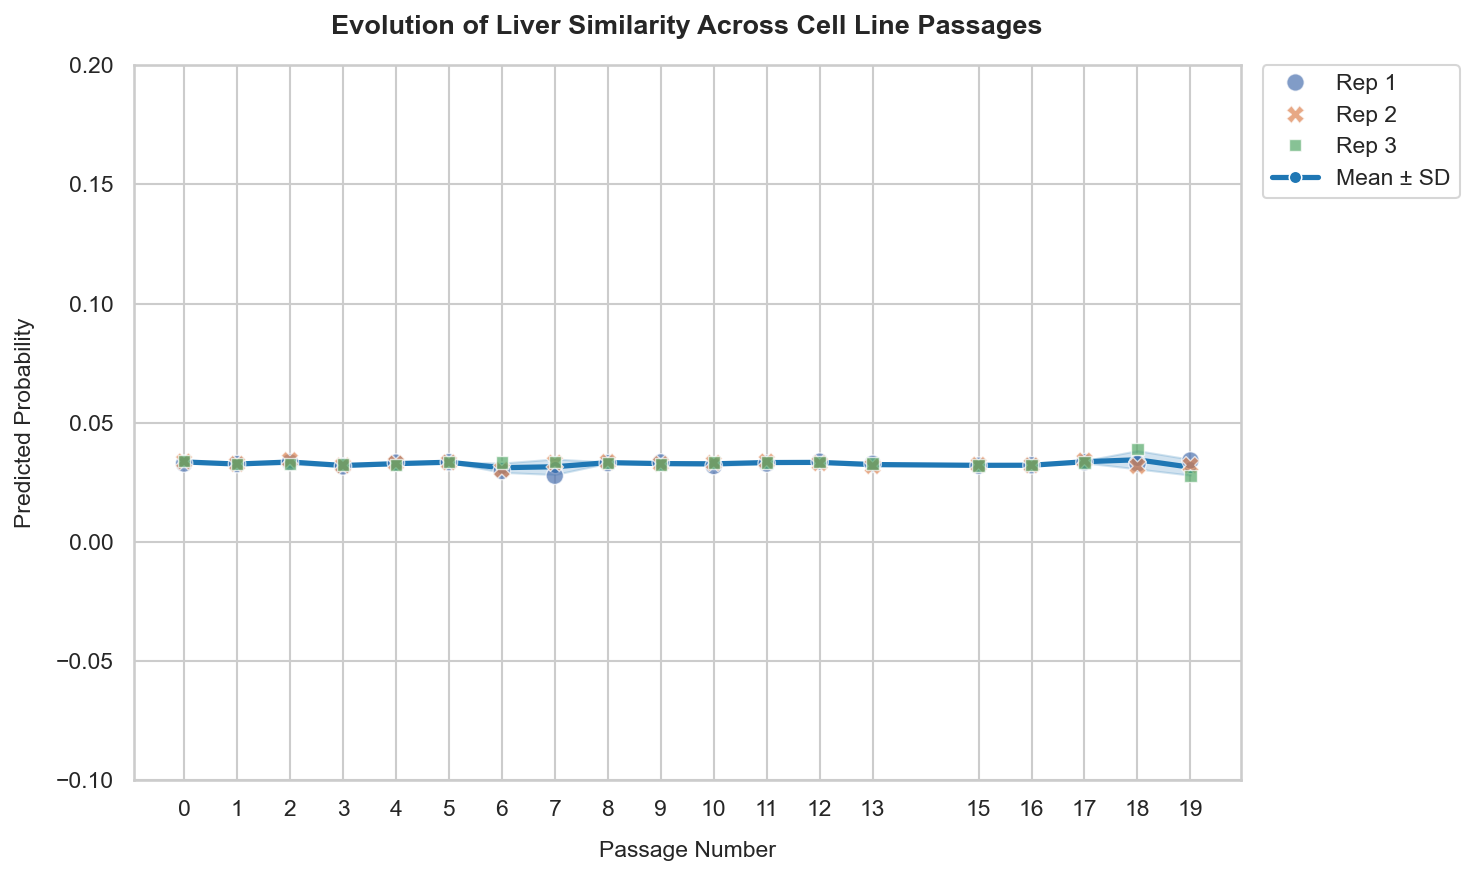

In [22]:
df_liver = df_predictions_long[df_predictions_long["Tissue"].str.lower() == "liver"].copy()

plt.figure(figsize=(10, 6), dpi=150)
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df_liver, x="Passage", y="Probability", hue="Replicate", style="Replicate",
    s=70, alpha=0.7, zorder=3,
)
sns.lineplot(
    data=df_liver, x="Passage", y="Probability", color="#1f77b4", linewidth=2.5,
    errorbar="sd", marker="o", markersize=6, label="Mean ± SD", zorder=2,
)

plt.title("Evolution of Liver Similarity Across Cell Line Passages", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Passage Number", fontsize=11, labelpad=10)
plt.ylabel("Predicted Probability", fontsize=11, labelpad=10)
plt.xticks(df_liver["Passage"].unique().astype(int))

# Custom y-axis ticks: -1.5 to 0.2 in steps of 0.05
plt.ylim(-0.1, 0.2)
plt.yticks(np.arange(-0.1, 0.2 + 0.05, 0.05))

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

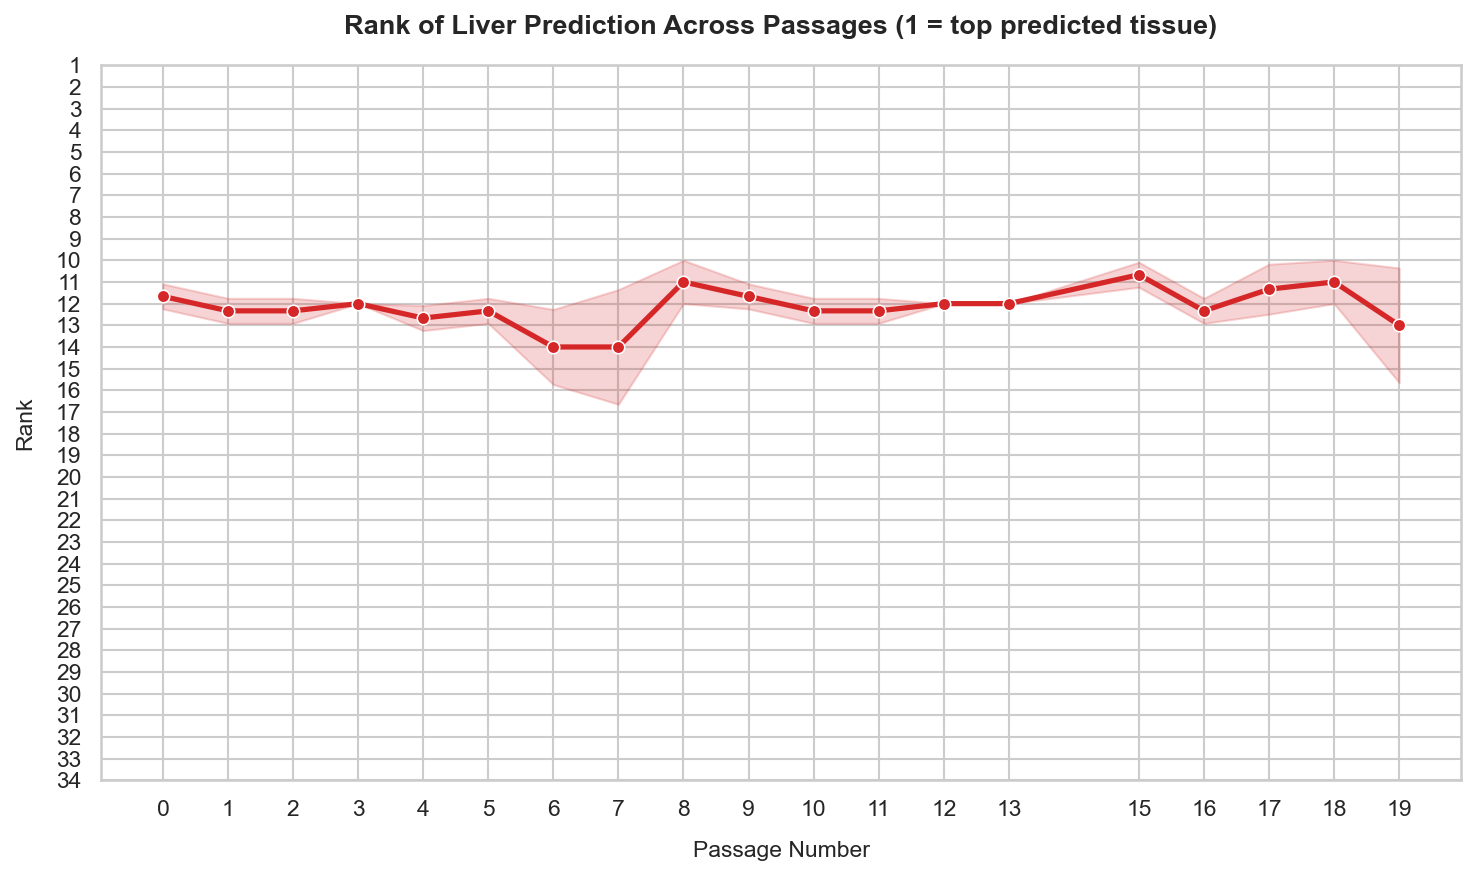

In [23]:
# Companion plot: Liver's RANK (1 = top prediction) across passages.
# This makes it obvious when/if another tissue (e.g. B-cell) overtakes Liver.
plt.figure(figsize=(10, 6), dpi=150)
sns.lineplot(
    data=df_liver, x="Passage", y="Rank", color="#d62728", linewidth=2.5,
    errorbar="sd", marker="o", markersize=6, zorder=2,
)

plt.ylim(1, 34)
plt.yticks(np.arange(1, 35, 1))  # 1, 2, 3, ..., 34
plt.gca().invert_yaxis()  # rank 1 at the top

plt.title("Rank of Liver Prediction Across Passages (1 = top predicted tissue)", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Passage Number", fontsize=11, labelpad=10)
plt.ylabel("Rank", fontsize=11, labelpad=10)
plt.xticks(df_liver["Passage"].unique().astype(int))
plt.tight_layout()
plt.show()

## 6. SHAP driver extraction


In [24]:
def get_top_bottom_shap(shap_results, tissue, n=N_SHAP_DRIVERS_EACH):
    """
    For each sample's SHAP dataframe, pull the n most negative and n most
    positive SHAP values for the given tissue row, and combine into one
    long-format summary dataframe.
    """
    summary_list = []

    for sample_id, df in shap_results.items():
        if tissue not in df.index:
            continue

        tissue_values = df.loc[tissue].sort_values()

        lowest_n = tissue_values.head(n)
        highest_n = tissue_values.tail(n)

        combined = pd.concat([lowest_n, highest_n])
        combined = combined[~combined.index.duplicated(keep="first")]

        sample_str = str(sample_id)
        parts = sample_str.split("_")

        raw_passage = int(parts[0])
        passage_num = raw_passage - 1
        replicate_id = int(parts[1]) if len(parts) > 1 else 1

        sample_summary = combined.to_frame(name="SHAP_Value")
        sample_summary["Sample_ID"] = sample_str
        sample_summary["Passage"] = passage_num
        sample_summary["Replicate"] = replicate_id
        sample_summary["Protein"] = sample_summary.index
        sample_summary["Tissue"] = tissue

        summary_list.append(sample_summary)

    if not summary_list:
        print(f"No data found for tissue '{tissue}'.")
        return pd.DataFrame()

    result_df = pd.concat(summary_list).reset_index(drop=True)
    result_df = result_df.sort_values(by=["Passage", "Replicate"]).reset_index(drop=True)
    result_df = result_df[["Sample_ID", "Passage", "Replicate", "Protein", "Tissue", "SHAP_Value"]]
    return result_df


# Liver drivers
final_summary_df = get_top_bottom_shap(shap_results, "Liver")
final_summary_df

,Sample_ID,Passage,Replicate,Protein,Tissue,SHAP_Value
0,1_1,0,1,P62805,Liver,-0.00296
1,1_1,0,1,Q15050,Liver,-0.00259
2,1_1,0,1,Q9UQE7,Liver,-0.00250
3,1_1,0,1,P13647,Liver,-0.00210
4,1_1,0,1,P11047,Liver,-0.00119
...,...,...,...,...,...,...
2275,20_3,19,3,P13498,Liver,0.00135
2276,20_3,19,3,P05177,Liver,0.00151
2277,20_3,19,3,O95487,Liver,0.00214
2278,20_3,19,3,P35573,Liver,0.00515


In [25]:
# B-cell drivers, same structure as Liver
bcell_tissue_label = "B-cells"

final_summary_df_bcells = get_top_bottom_shap(shap_results, bcell_tissue_label)
final_summary_df_bcells

,Sample_ID,Passage,Replicate,Protein,Tissue,SHAP_Value
0,1_1,0,1,P19013,B-cells,-0.01701
1,1_1,0,1,Q9Y678,B-cells,-0.00741
2,1_1,0,1,P54886,B-cells,-0.00518
3,1_1,0,1,P09543,B-cells,-0.00450
4,1_1,0,1,P35580,B-cells,-0.00354
...,...,...,...,...,...,...
2275,20_3,19,3,P12270,B-cells,0.01029
2276,20_3,19,3,Q15050,B-cells,0.01120
2277,20_3,19,3,A6NHR9,B-cells,0.01187
2278,20_3,19,3,Q96SB8,B-cells,0.01459
